# Threshold Distribution Across Trial Labels

When `p-active-per-trial` is set to `True` during zigzag computation, an individual
activation threshold is estimated for each trial. This notebook loads those per-trial
thresholds, joins them with trial metadata to obtain video-type labels, and visualises
the threshold distributions split by label for each mouse.

**For each mouse:**
- Histogram of threshold values per label (overlapping, semi-transparent)
- Boxplot of threshold values per label

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make scripts/utils.py importable
SCRIPTS_DIR = Path("../scripts").resolve()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import utils as utils_module
utils_module = importlib.reload(utils_module)

_extract_trial_id_from_name = utils_module._extract_trial_id_from_name
_short_mouse_name = utils_module._short_mouse_name
load_trial_metadata = utils_module.load_trial_metadata

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────

ROOT_PATH = Path(
    "/orfeo/scratch/area/ygardinazzi/sensorium_2026/derivatives/"
    "grid-15x15x10_norm-by_minmax"
)
META_ROOT = Path("/u/mdmc/anaflom/projects_mdmc/sensorium/metadata")

P_ACTIVE = 30  # percentile used when computing zigzag thresholds

# Discover all mouse directories automatically
MICE = sorted(
    d.name for d in ROOT_PATH.iterdir()
    if d.is_dir() and d.name.startswith("dynamic")
)
print(f"Found {len(MICE)} mice:")
for m in MICE:
    print(f"  {m}")

Found 10 mice:
  dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce
  dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce
  dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce
  dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce
  dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce
  dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20
  dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20
  dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20
  dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20
  dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20


In [3]:
def load_threshold_df(mouse_id: str) -> pd.DataFrame:
    """Load per-trial thresholds for one mouse and join with trial metadata.

    Returns a DataFrame with columns: trial_id, threshold, label.
    Rows where the trial ID cannot be parsed or is absent from metadata
    are dropped with a printed warning.
    """
    zz_folder = f"trials_zz-thresh-{P_ACTIVE}-per-trial"
    csv_path = ROOT_PATH / mouse_id / zz_folder / f"zz-thresh-{P_ACTIVE}-per-trial_trial_thresholds.csv"

    if not csv_path.exists():
        print(f"[{mouse_id}] Threshold CSV not found: {csv_path}")
        return pd.DataFrame(columns=["trial_id", "threshold", "label"])

    df_thresh = pd.read_csv(csv_path)

    # Extract numeric trial ID from the grid filename stored in the 'trial' column
    df_thresh["trial_id"] = df_thresh["trial"].apply(
        lambda name: _extract_trial_id_from_name(Path(name))
    )

    n_unparsed = df_thresh["trial_id"].isna().sum()
    if n_unparsed > 0:
        print(f"[{mouse_id}] Warning: could not parse trial ID for {n_unparsed} rows — dropping.")
    df_thresh = df_thresh.dropna(subset=["trial_id"])
    df_thresh["trial_id"] = df_thresh["trial_id"].astype(int)

    # Load metadata and join on trial ID
    try:
        df_meta = load_trial_metadata(META_ROOT, mouse_id)
    except FileNotFoundError as exc:
        print(f"[{mouse_id}] Metadata not found: {exc}")
        return pd.DataFrame(columns=["trial_id", "threshold", "label"])

    df_meta = df_meta[["trial", "label"]].rename(columns={"trial": "trial_id"})
    df_meta["trial_id"] = df_meta["trial_id"].astype(int)

    df_merged = df_thresh.merge(df_meta, on="trial_id", how="left")

    n_no_label = df_merged["label"].isna().sum()
    if n_no_label > 0:
        print(f"[{mouse_id}] Warning: {n_no_label} trials have no matching metadata label — dropping.")
    df_merged = df_merged.dropna(subset=["label"])

    return df_merged[["trial_id", "threshold", "label"]].reset_index(drop=True)

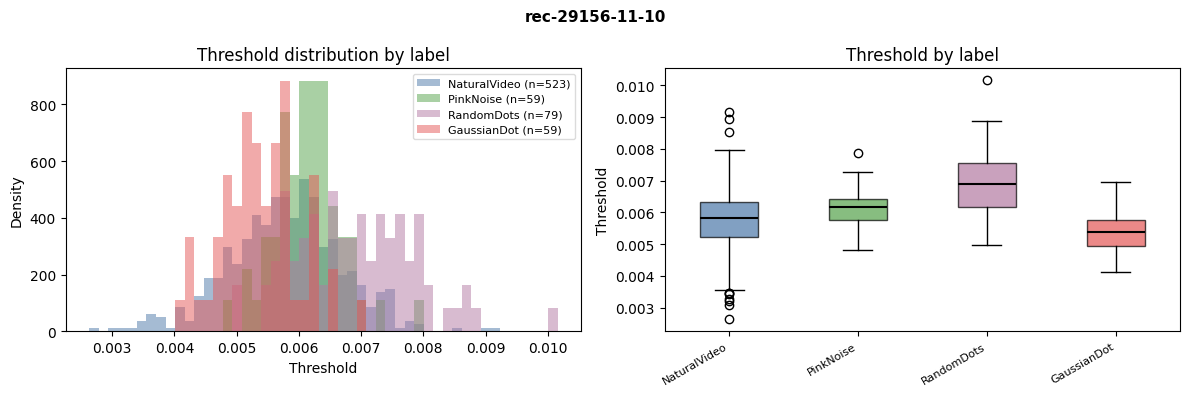

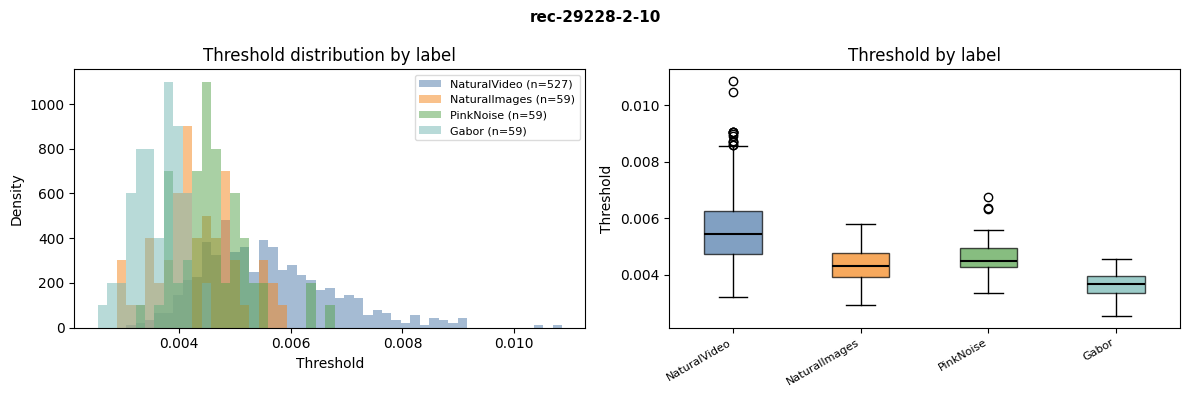

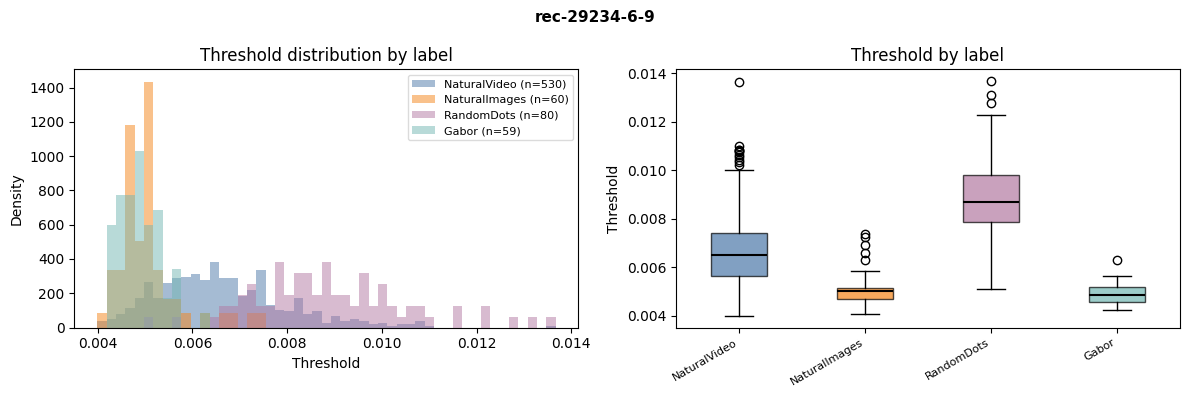

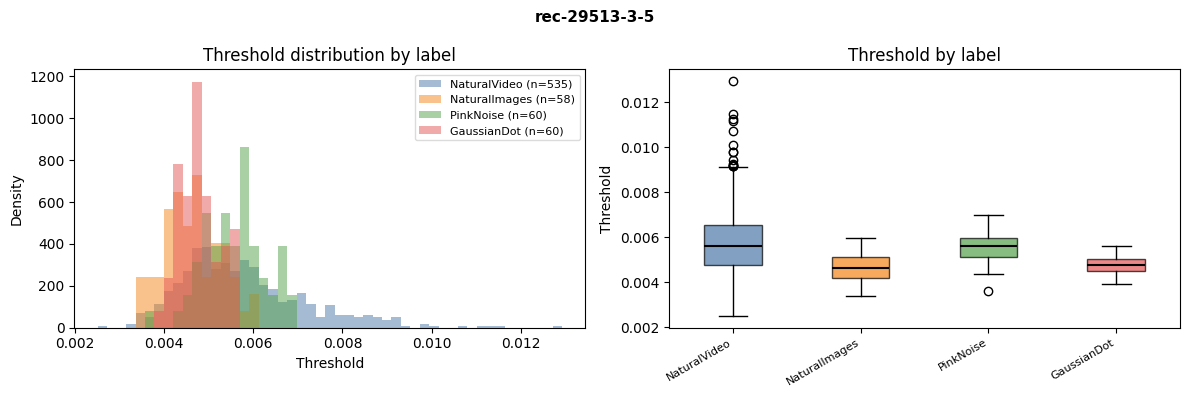

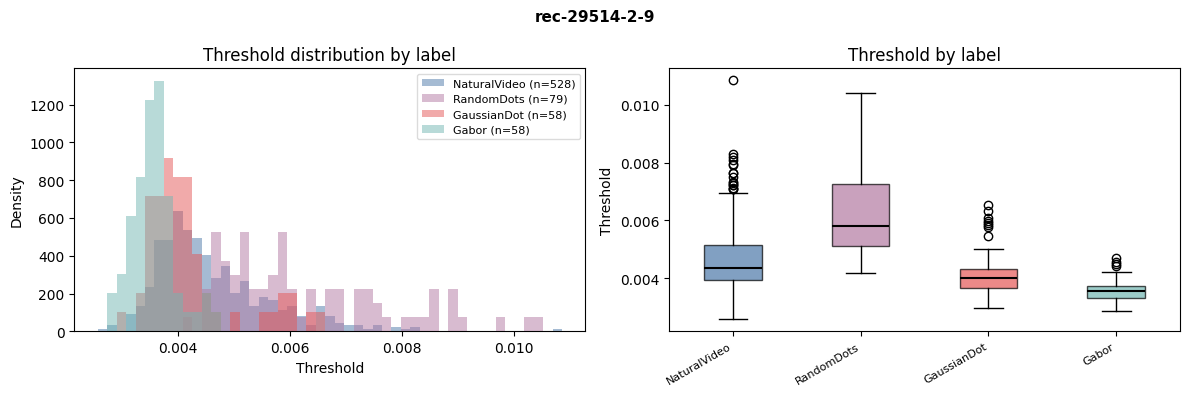

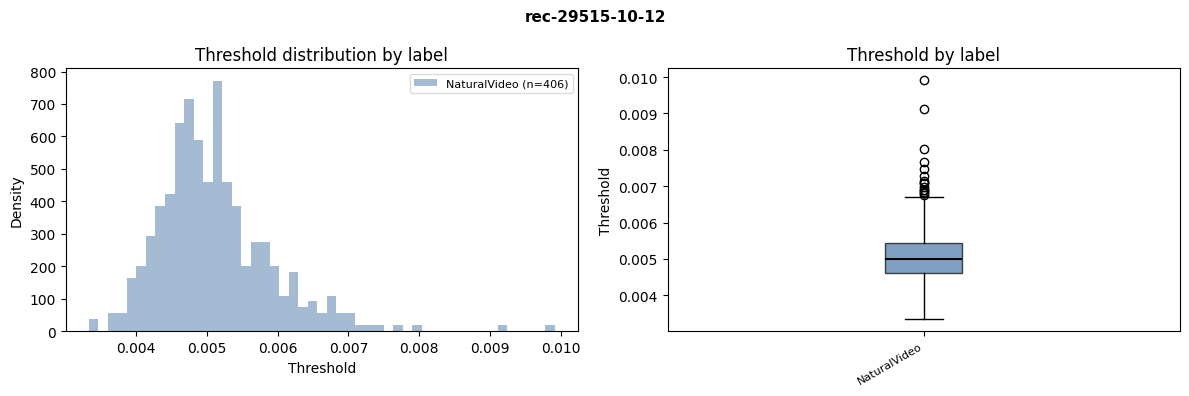

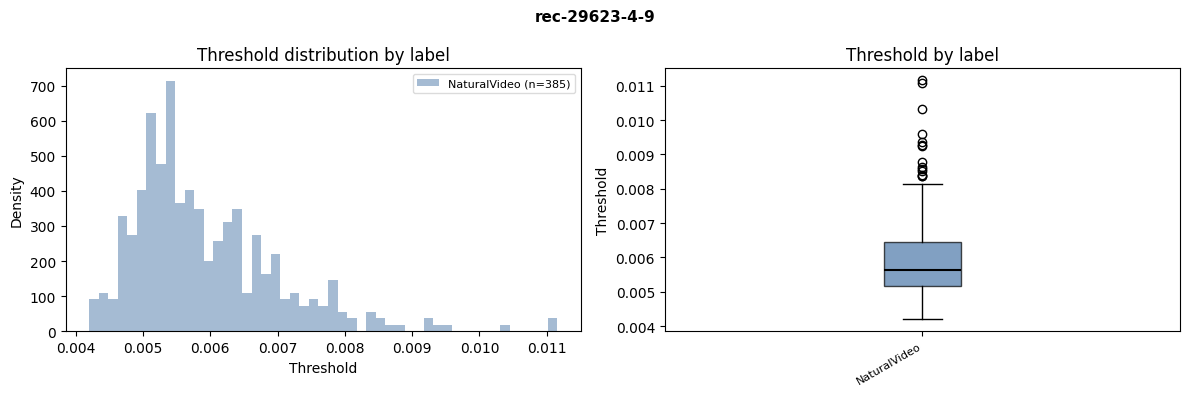

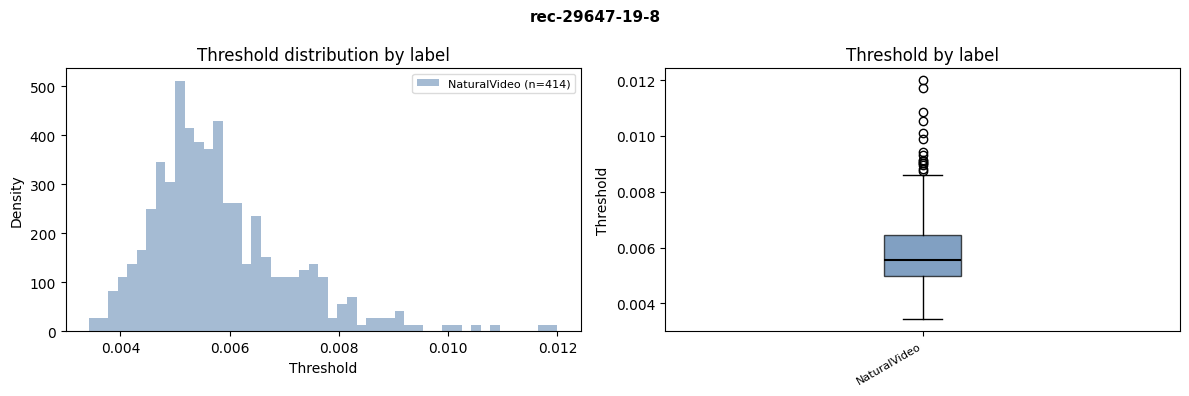

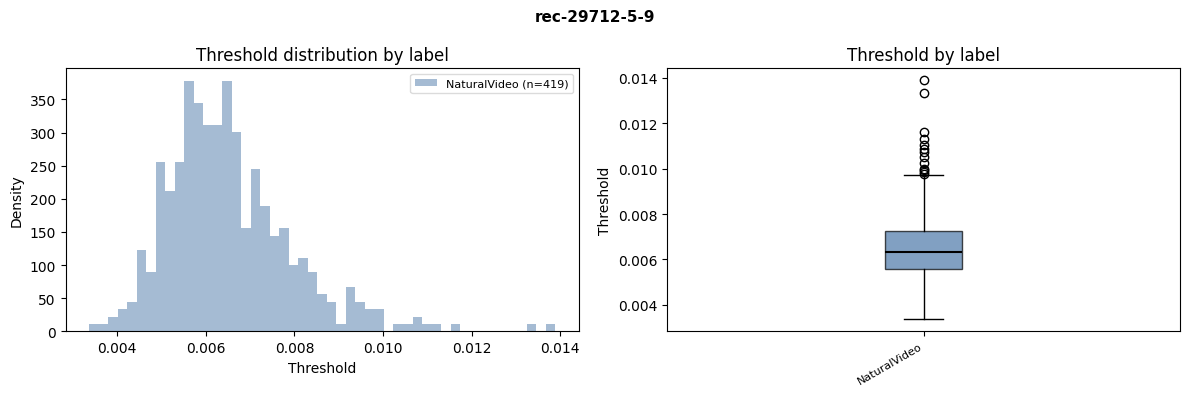

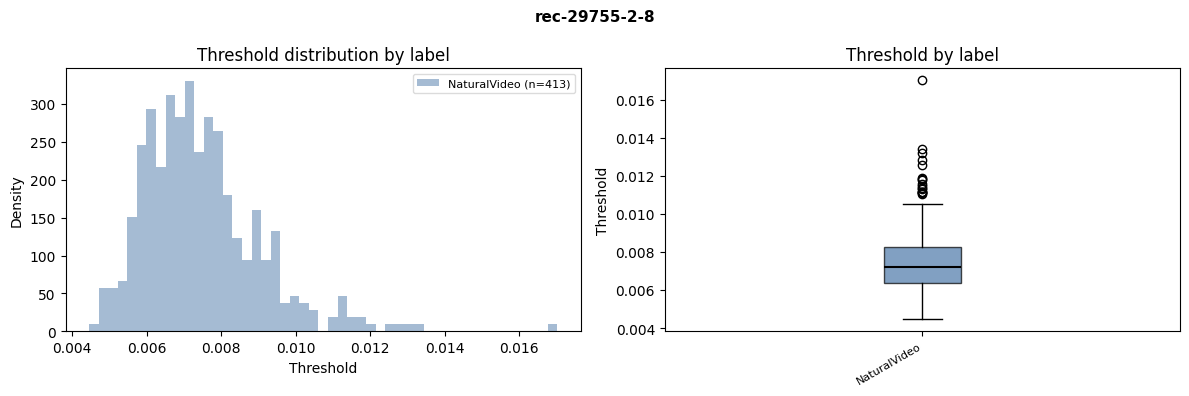

In [10]:
# ── Plot threshold distributions for every mouse ───────────────────────────────
labels_order = ["NaturalVideo", "NaturalImages", "PinkNoise", "RandomDots", "GaussianDot", "Gabor"]
label_colours = {
    "NaturalVideo": "#4C78A8",
    "NaturalImages": "#F58518",
    "PinkNoise": "#54A24B",
    "RandomDots": "#B279A2",
    "GaussianDot": "#E45756",
    "Gabor": "#72B7B2",
}

for mouse_id in MICE:
    df = load_threshold_df(mouse_id)

    if df.empty:
        print(f"[{mouse_id}] No data — skipping.")
        continue

    present_labels = list(df["label"].dropna().unique())
    ordered_labels = [label for label in labels_order if label in present_labels]
    extra_labels = sorted(label for label in present_labels if label not in labels_order)
    labels = ordered_labels + extra_labels
    n_labels = len(labels)

    fallback_cmap = plt.get_cmap("tab10")
    colours = {
        lbl: label_colours.get(lbl, fallback_cmap(i % 10))
        for i, lbl in enumerate(labels)
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(_short_mouse_name(mouse_id), fontsize=11, fontweight="bold")

    # ── Left: overlapping histograms ──────────────────────────────────────────
    ax_hist = axes[0]
    all_thresholds = df["threshold"].values
    all_thresholds = -all_thresholds  # Invert so that higher values correspond to more "active" trials
    bins = np.linspace(all_thresholds.min(), all_thresholds.max(), 50)

    for lbl in labels:
        vals = df.loc[df["label"] == lbl, "threshold"].values
        vals = -vals  # Invert so that higher values correspond to more "active" trials
        ax_hist.hist(
            vals,
            bins=bins,
            alpha=0.5,
            label=f"{lbl} (n={len(vals)})",
            color=colours[lbl],
            edgecolor="none",
            density=True,
        )

    ax_hist.set_xlabel("Threshold")
    ax_hist.set_ylabel("Density")
    ax_hist.set_title("Threshold distribution by label")
    ax_hist.legend(fontsize=8, framealpha=0.7)

    # ── Right: boxplot ────────────────────────────────────────────────────────
    ax_box = axes[1]
    group_data = [-df.loc[df["label"] == lbl, "threshold"].values for lbl in labels]
    bp = ax_box.boxplot(
        group_data,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.5),
    )
    for patch, lbl in zip(bp["boxes"], labels):
        patch.set_facecolor(colours[lbl])
        patch.set_alpha(0.7)

    ax_box.set_xticks(range(1, n_labels + 1))
    ax_box.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax_box.set_ylabel("Threshold")
    ax_box.set_title("Threshold by label")

    plt.tight_layout()
    plt.show()

## Per-Mouse Statistical Analysis

All inferential analyses below are run **separately for each mouse** using:

- Mixed-effects model: `threshold_active ~ C(label)`
- OLS model: `threshold_active ~ C(label)`
- Multiple comparisons between labels **within each mouse** (Holm-corrected pairwise contrasts, with Tukey fallback)

where `threshold_active = -threshold`.

In [4]:
import statsmodels.formula.api as smf

if "labels_order" not in globals():
    labels_order = [
        "NaturalVideo",
        "NaturalImages",
        "PinkNoise",
        "RandomDots",
        "GaussianDot",
        "Gabor",
    ]

# Build per-mouse datasets once
per_mouse_data = {}
for mouse_id in MICE:
    df_mouse = load_threshold_df(mouse_id)
    if df_mouse.empty:
        continue

    df_mouse = df_mouse.copy()
    df_mouse["mouse"] = _short_mouse_name(mouse_id)
    df_mouse["threshold_active"] = -df_mouse["threshold"]

    present_labels = list(df_mouse["label"].dropna().unique())
    ordered_labels = [label for label in labels_order if label in present_labels]
    extra_labels = sorted(label for label in present_labels if label not in labels_order)
    label_levels = ordered_labels + extra_labels
    df_mouse["label"] = pd.Categorical(df_mouse["label"], categories=label_levels, ordered=True)

    per_mouse_data[df_mouse["mouse"].iloc[0]] = df_mouse[["trial_id", "label", "threshold_active"]].reset_index(drop=True)

if not per_mouse_data:
    raise RuntimeError("No per-mouse threshold rows available.")

print(f"Per-mouse datasets available: {len(per_mouse_data)}")
for mouse_name, df_mouse in per_mouse_data.items():
    n_labels = df_mouse["label"].nunique()
    print(f"  {mouse_name}: n={len(df_mouse)}, labels={n_labels}")

print("\n=== Per-mouse mixed-effects models ===")
mixed_results = {}

for mouse_name, df_mouse in per_mouse_data.items():
    n_labels = df_mouse["label"].nunique()
    if n_labels < 2:
        print(f"\n[{mouse_name}] skipped (needs at least 2 labels)")
        continue

    print(f"\n[{mouse_name}] MixedLM: threshold_active ~ C(label)")
    print(f"Rows={len(df_mouse)}, Labels={n_labels}")

    # Per-mouse mixed model: random intercept by label.
    # This keeps the mixed-effects framework while estimating label fixed effects within mouse.
    try:
        model = smf.mixedlm(
            "threshold_active ~ C(label)",
            data=df_mouse,
            groups=df_mouse["label"],
            re_formula="1",
        )
        result = model.fit(reml=True, method="lbfgs")
        mixed_results[mouse_name] = result

        display(result.summary())

        fe = result.fe_params.rename("coef").to_frame()
        ci = result.conf_int()
        fe["ci_low"] = ci.loc[fe.index, 0]
        fe["ci_high"] = ci.loc[fe.index, 1]
        print("Fixed effects (95% CI):")
        display(fe)
    except Exception as exc:
        print(f"MixedLM failed for {mouse_name}: {exc}")

Per-mouse datasets available: 10
  rec-29156-11-10: n=720, labels=4
  rec-29228-2-10: n=704, labels=4
  rec-29234-6-9: n=729, labels=4
  rec-29513-3-5: n=713, labels=4
  rec-29514-2-9: n=723, labels=4
  rec-29515-10-12: n=406, labels=1
  rec-29623-4-9: n=385, labels=1
  rec-29647-19-8: n=414, labels=1
  rec-29712-5-9: n=419, labels=1
  rec-29755-2-8: n=413, labels=1

=== Per-mouse mixed-effects models ===

[rec-29156-11-10] MixedLM: threshold_active ~ C(label)
Rows=720, Labels=4


/u/mdmc/anaflom/projects_mdmc/ZigZagSensorium/.venv-genoa/lib64/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
               Mixed Linear Model Regression Results
===================================================================
Model:               MixedLM  Dependent Variable:  threshold_active
No. Observations:    720      Method:              REML            
No. Groups:          4        Scale:               0.0000          
Min. group size:     59       Log-Likelihood:      4012.9033       
Max. group size:     523      Converged:           Yes             
Mean group size:     180.0                                         
-------------------------------------------------------------------
                        Coef.   Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                0.006     0.001  6.572 0.000  0.004  0.008
C(label)[T.PinkNoise]    0.000     0.001  0.285 0.776 -0.002  0.003
C(label)[T.RandomDots]   0.001     0.001  0.897 0.370 -0.001  0.004
C(label)[T.GaussianDot] -0.000     0.001 -0.325 0.745 -0.003  0.002
Group Var                0.000 19664.002                           
===================================================================

"""

Fixed effects (95% CI):


,coef,ci_low,ci_high
Intercept,0.005783,0.004058,0.007508
C(label)[T.PinkNoise],0.000355,-0.002093,0.002803
C(label)[T.RandomDots],0.001119,-0.001326,0.003565
C(label)[T.GaussianDot],-0.000406,-0.002854,0.002042


...

/u/mdmc/anaflom/projects_mdmc/ZigZagSensorium/.venv-genoa/lib64/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/u/mdmc/anaflom/projects_mdmc/ZigZagSensorium/.venv-genoa/lib64/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
==================================================================
Model:              MixedLM  Dependent Variable:  threshold_active
No. Observations:   723      Method:              REML            
No. Groups:         4        Scale:               0.0000          
Min. group size:    58       Log-Likelihood:      3906.8576       
Max. group size:    528      Converged:           Yes             
Mean group size:    180.8                                         
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                0.005    0.001  4.443 0.000  0.003  0.007
C(label)[T.RandomDots]   0.002    0.001  1.108 0.268 -0.001  0.005
C(label)[T.GaussianDot] -0.000    0.001 -0.296 0.767 -0.003  0.002
C(label)[T.Gabor]       -0.001    0.001 -0.723 0.470 -0.004  0.002
Group Var                0.000                                    
==================================================================

"""

Fixed effects (95% CI):


,coef,ci_low,ci_high
Intercept,0.004638,0.002592,0.006684
C(label)[T.RandomDots],0.001640,-0.001261,0.004542
C(label)[T.GaussianDot],-0.000439,-0.003343,0.002466
C(label)[T.Gabor],-0.001072,-0.003976,0.001833



[rec-29515-10-12] skipped (needs at least 2 labels)

[rec-29623-4-9] skipped (needs at least 2 labels)

[rec-29647-19-8] skipped (needs at least 2 labels)

[rec-29712-5-9] skipped (needs at least 2 labels)

[rec-29755-2-8] skipped (needs at least 2 labels)


In [5]:
# Per-mouse OLS + multiple comparisons between labels
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("=== Per-mouse OLS and pairwise label contrasts ===")
ols_results = {}
pairwise_results = {}

for mouse_name, df_mouse in per_mouse_data.items():
    n_labels = df_mouse["label"].nunique()
    if n_labels < 2:
        print(f"\n[{mouse_name}] skipped (needs at least 2 labels)")
        continue

    print(f"\n[{mouse_name}] OLS: threshold_active ~ C(label)")
    print(f"Rows={len(df_mouse)}, Labels={n_labels}")

    ols_model = smf.ols("threshold_active ~ C(label)", data=df_mouse)
    ols_result = ols_model.fit()
    ols_results[mouse_name] = ols_result

    display(ols_result.summary())

    coef_table = ols_result.params.rename("coef").to_frame()
    ci_ols = ols_result.conf_int()
    coef_table["ci_low"] = ci_ols.loc[coef_table.index, 0]
    coef_table["ci_high"] = ci_ols.loc[coef_table.index, 1]
    print("OLS coefficients (95% CI):")
    display(coef_table)

    print("Pairwise label comparisons (within mouse, Holm correction):")
    try:
        ph = ols_result.t_test_pairwise("C(label)", method="holm")
        pairwise_results[mouse_name] = ph.result_frame
        display(ph.result_frame)
    except Exception as exc:
        print(f"Model-based pairwise contrasts unavailable ({exc}). Falling back to Tukey HSD.")
        tukey = pairwise_tukeyhsd(
            endog=df_mouse["threshold_active"],
            groups=df_mouse["label"],
            alpha=0.05,
        )
        tukey_df = pd.DataFrame(
            tukey._results_table.data[1:],
            columns=tukey._results_table.data[0],
        )
        pairwise_results[mouse_name] = tukey_df
        display(tukey_df)

=== Per-mouse OLS and pairwise label contrasts ===

[rec-29156-11-10] OLS: threshold_active ~ C(label)
Rows=720, Labels=4


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       threshold_active   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     45.74
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           4.72e-27
Time:                        14:35:36   Log-Likelihood:                 4046.8
No. Observations:                 720   AIC:                            -8086.
Df Residuals:                     716   BIC:                            -8067.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.0058   3.84e-05    150.450      0.000       0.006       0.006
C(label)[T.PinkNoise]       0.0004      0.000      2.944      0.003       0.000       0.001
C(label)[T.RandomDots]      0.0011      0.000     10.550      0.000       0.001       0.001
C(label)[T.GaussianDot]    -0.0004      0.000     -3.363      0.001      -0.001      -0.000
==============================================================================
Omnibus:                       11.142   Durbin-Watson:                   1.762
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               18.438
Skew:                           0.019   Prob(JB):                     9.91e-05
Kurtosis:                       3.783   Cond. No.                         4.06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

OLS coefficients (95% CI):


,coef,ci_low,ci_high
Intercept,0.005783,0.005708,0.005858
C(label)[T.PinkNoise],0.000355,0.000118,0.000592
C(label)[T.RandomDots],0.001119,0.000911,0.001328
C(label)[T.GaussianDot],-0.000406,-0.000643,-0.000169


Pairwise label comparisons (within mouse, Holm correction):


...

OLS coefficients (95% CI):


,coef,ci_low,ci_high
Intercept,0.004638,0.004549,0.004727
C(label)[T.RandomDots],0.001640,0.001393,0.001887
C(label)[T.GaussianDot],-0.000439,-0.000722,-0.000155
C(label)[T.Gabor],-0.001072,-0.001355,-0.000788


Pairwise label comparisons (within mouse, Holm correction):


,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-holm,reject-holm
RandomDots-NaturalVideo,0.001640,0.000126,13.038723,4.926351e-35,0.001393,0.001887,2.463176e-34,True
GaussianDot-NaturalVideo,-0.000439,0.000144,-3.039995,2.451684e-03,-0.000722,-0.000155,2.451684e-03,True
Gabor-NaturalVideo,-0.001072,0.000144,-7.428309,3.124877e-13,-0.001355,-0.000788,9.374632e-13,True
GaussianDot-RandomDots,-0.002079,0.000180,-11.528298,2.469896e-28,-0.002433,-0.001725,9.879586e-28,True
Gabor-RandomDots,-0.002712,0.000180,-15.038910,1.203600e-44,-0.003066,-0.002358,7.221599e-44,True
Gabor-GaussianDot,-0.000633,0.000194,-3.268997,1.130668e-03,-0.001013,-0.000253,2.261335e-03,True



[rec-29515-10-12] skipped (needs at least 2 labels)

[rec-29623-4-9] skipped (needs at least 2 labels)

[rec-29647-19-8] skipped (needs at least 2 labels)

[rec-29712-5-9] skipped (needs at least 2 labels)

[rec-29755-2-8] skipped (needs at least 2 labels)


In [6]:
# Aggregate per-mouse statistical results into tidy DataFrames
from pathlib import Path

# 1) Mixed-effects fixed effects
mixed_rows = []
for mouse_name, res in mixed_results.items():
    ci_m = res.conf_int()
    for term, coef in res.fe_params.items():
        mixed_rows.append({
            "mouse": mouse_name,
            "model": "MixedLM",
            "result_type": "fixed_effect",
            "term": term,
            "coef": float(coef),
            "ci_low": float(ci_m.loc[term, 0]),
            "ci_high": float(ci_m.loc[term, 1]),
            "p_value": float(res.pvalues.get(term, float("nan"))),
        })

df_mixed_agg = pd.DataFrame(mixed_rows)

# 2) OLS coefficients
ols_rows = []
for mouse_name, res in ols_results.items():
    ci_o = res.conf_int()
    for term, coef in res.params.items():
        ols_rows.append({
            "mouse": mouse_name,
            "model": "OLS",
            "result_type": "coefficient",
            "term": term,
            "coef": float(coef),
            "ci_low": float(ci_o.loc[term, 0]),
            "ci_high": float(ci_o.loc[term, 1]),
            "p_value": float(res.pvalues.get(term, float("nan"))),
        })

df_ols_agg = pd.DataFrame(ols_rows)

# 3) Within-mouse pairwise comparisons
pairwise_rows = []
for mouse_name, df_pw in pairwise_results.items():
    df_local = df_pw.copy()
    df_local = df_local.rename(
        columns={
            "pvalue-holm": "p_value_adj_holm",
            "reject-holm": "reject_holm",
            "P>|t|": "p_value",
            "Conf. Int. Low": "ci_low",
            "Conf. Int. Upp.": "ci_high",
        }
    )
    comparison_col = df_local.index if df_local.index.name is not None else df_local.index
    df_local = df_local.reset_index().rename(columns={"index": "comparison"})
    df_local["mouse"] = mouse_name
    df_local["model"] = "OLS"
    df_local["result_type"] = "pairwise_label_comparison"
    pairwise_rows.append(df_local)

df_pairwise_agg = pd.concat(pairwise_rows, ignore_index=True) if pairwise_rows else pd.DataFrame()

# Unified aggregated table
common_cols = ["mouse", "model", "result_type"]
df_stats_agg = pd.concat([
    df_mixed_agg,
    df_ols_agg,
    df_pairwise_agg,
], ignore_index=True, sort=False)

print("Aggregated shapes:")
print(f"  MixedLM fixed effects: {df_mixed_agg.shape}")
print(f"  OLS coefficients:      {df_ols_agg.shape}")
print(f"  Pairwise contrasts:    {df_pairwise_agg.shape}")
print(f"  Unified table:         {df_stats_agg.shape}")

display(df_stats_agg.head(20))

# Optional export
EXPORT_CSV = False
if EXPORT_CSV:
    out_csv = Path("../results/threshold_stats_per_mouse_aggregated.csv").resolve()
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df_stats_agg.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")

Aggregated shapes:
  MixedLM fixed effects: (20, 8)
  OLS coefficients:      (20, 8)
  Pairwise contrasts:    (30, 12)
  Unified table:         (70, 13)


,mouse,model,result_type,term,coef,ci_low,ci_high,p_value,comparison,std err,t,p_value_adj_holm,reject_holm
0,rec-29156-11-10,MixedLM,fixed_effect,Intercept,0.005783,0.004058,0.007508,4.949226e-11,NaN,NaN,NaN,NaN,NaN
1,rec-29156-11-10,MixedLM,fixed_effect,C(label)[T.PinkNoise],0.000355,-0.002093,0.002803,7.759814e-01,NaN,NaN,NaN,NaN,NaN
2,rec-29156-11-10,MixedLM,fixed_effect,C(label)[T.RandomDots],0.001119,-0.001326,0.003565,3.695887e-01,NaN,NaN,NaN,NaN,NaN
3,rec-29156-11-10,MixedLM,fixed_effect,C(label)[T.GaussianDot],-0.000406,-0.002854,0.002042,7.451668e-01,NaN,NaN,NaN,NaN,NaN
4,rec-29228-2-10,MixedLM,fixed_effect,Intercept,0.005601,0.003495,0.007707,1.857502e-07,NaN,NaN,NaN,NaN,NaN
5,rec-29228-2-10,MixedLM,fixed_effect,C(label)[T.NaturalImages],-0.001261,-0.004250,0.001729,4.084831e-01,NaN,NaN,NaN,NaN,NaN
6,rec-29228-2-10,MixedLM,fixed_effect,C(label)[T.PinkNoise],-0.000974,-0.003964,0.002015,5.229296e-01,NaN,NaN,NaN,NaN,NaN
7,rec-29228-2-10,MixedLM,fixed_effect,C(label)[T.Gabor],-0.001968,-0.004958,0.001021,1.968626e-01,NaN,NaN,NaN,NaN,NaN
8,rec-29234-6-9,MixedLM,fixed_effect,Intercept,0.006644,0.004060,0.009228,4.679700e-07,NaN,NaN,NaN,NaN,NaN
9,rec-29234-6-9,MixedLM,fixed_effect,C(label)[T.NaturalImages],-0.001575,-0.005243,0.002093,3.999812e-01,NaN,NaN,NaN,NaN,NaN


In [7]:
# Compact per-mouse summary tables from aggregated results
if "df_stats_agg" not in globals():
    raise RuntimeError("df_stats_agg is missing. Run Cell 9 first.")

# OLS/MixedLM coefficient summary (per mouse x term)
coef_summary = (
    df_stats_agg[df_stats_agg["result_type"].isin(["fixed_effect", "coefficient"])]
    .pivot_table(
        index=["mouse", "term"],
        columns=["model", "result_type"],
        values=["coef", "p_value"],
        aggfunc="first",
    )
    .sort_index()
    .round(6)
)

# Pairwise comparison compact summary
pairwise_summary = (
    df_stats_agg[df_stats_agg["result_type"] == "pairwise_label_comparison"]
    .loc[:, ["mouse", "comparison", "coef", "p_value", "p_value_adj_holm", "reject_holm"]]
    .sort_values(["mouse", "comparison"])
    .reset_index(drop=True)
    .round(6)
)

print("Coefficient summary shape:", coef_summary.shape)
display(coef_summary)

print("\nPairwise summary shape:", pairwise_summary.shape)
display(pairwise_summary.head(50))

# Optional exports
EXPORT_SUMMARY_CSV = False
if EXPORT_SUMMARY_CSV:
    out_dir = Path("../results").resolve()
    out_dir.mkdir(parents=True, exist_ok=True)
    coef_path = out_dir / "threshold_stats_per_mouse_coef_summary.csv"
    pairwise_path = out_dir / "threshold_stats_per_mouse_pairwise_summary.csv"
    coef_summary.reset_index().to_csv(coef_path, index=False)
    pairwise_summary.to_csv(pairwise_path, index=False)
    print(f"Saved: {coef_path}")
    print(f"Saved: {pairwise_path}")

Coefficient summary shape: (20, 4)


coef              \
model                                          MixedLM         OLS   
result_type                               fixed_effect coefficient   
mouse           term                                                 
rec-29156-11-10 C(label)[T.GaussianDot]      -0.000406   -0.000406   
                C(label)[T.PinkNoise]         0.000355    0.000355   
                C(label)[T.RandomDots]        0.001119    0.001119   
                Intercept                     0.005783    0.005783   
rec-29228-2-10  C(label)[T.Gabor]            -0.001968   -0.001968   
                C(label)[T.NaturalImages]    -0.001261   -0.001261   
                C(label)[T.PinkNoise]        -0.000974   -0.000974   
                Intercept                     0.005601    0.005601   
rec-29234-6-9   C(label)[T.Gabor]            -0.001756   -0.001756   
                C(label)[T.NaturalImages]    -0.001575   -0.001575   
                C(label)[T.RandomDots]        0.002239    0.002239   
                Intercept                     0.006644    0.006644   
rec-29513-3-5   C(label)[T.GaussianDot]      -0.001017   -0.001017   
                C(label)[T.NaturalImages]    -0.001182   -0.001182   
                C(label)[T.PinkNoise]        -0.000212   -0.000212   
                Intercept                     0.005801    0.005801   
rec-29514-2-9   C(label)[T.Gabor]            -0.001072   -0.001072   
                C(label)[T.GaussianDot]      -0.000439   -0.000439   
                C(label)[T.RandomDots]        0.001640    0.001640   
                Intercept                     0.004638    0.004638   

                                               p_value              
model                                          MixedLM         OLS  
result_type                               fixed_effect coefficient  
mouse           term                                                
rec-29156-11-10 C(label)[T.GaussianDot]       0.745167    0.000813  
                C(label)[T.PinkNoise]         0.775981    0.003345  
                C(label)[T.RandomDots]        0.369589    0.000000  
                Intercept                     0.000000    0.000000  
rec-29228-2-10  C(label)[T.Gabor]             0.196863    0.000000  
                C(label)[T.NaturalImages]     0.408483    0.000000  
                C(label)[T.PinkNoise]         0.522930    0.000000  
                Intercept                     0.000000    0.000000  
rec-29234-6-9   C(label)[T.Gabor]             0.348193    0.000000  
                C(label)[T.NaturalImages]     0.399981    0.000000  
                C(label)[T.RandomDots]        0.230955    0.000000  
                Intercept                     0.000000    0.000000  
rec-29513-3-5   C(label)[T.GaussianDot]       0.578519    0.000000  
                C(label)[T.NaturalImages]     0.518321    0.000000  
                C(label)[T.PinkNoise]         0.907849    0.227477  
                Intercept                     0.000007    0.000000  
rec-29514-2-9   C(label)[T.Gabor]             0.469591    0.000000  
                C(label)[T.GaussianDot]       0.767274    0.002452  
                C(label)[T.RandomDots]        0.267785    0.000000  
                Intercept                     0.000009    0.000000


Pairwise summary shape: (30, 6)


,mouse,comparison,coef,p_value,p_value_adj_holm,reject_holm
0,rec-29156-11-10,GaussianDot-NaturalVideo,-0.000406,0.000813,0.001626,True
1,rec-29156-11-10,GaussianDot-PinkNoise,-0.000761,0.000003,0.000009,True
2,rec-29156-11-10,GaussianDot-RandomDots,-0.001525,0.000000,0.000000,True
3,rec-29156-11-10,PinkNoise-NaturalVideo,0.000355,0.003345,0.003345,True
4,rec-29156-11-10,RandomDots-NaturalVideo,0.001119,0.000000,0.000000,True
5,rec-29156-11-10,RandomDots-PinkNoise,0.000764,0.000001,0.000002,True
6,rec-29228-2-10,Gabor-NaturalImages,-0.000708,0.000366,0.000733,True
7,rec-29228-2-10,Gabor-NaturalVideo,-0.001968,0.000000,0.000000,True
8,rec-29228-2-10,Gabor-PinkNoise,-0.000994,0.000001,0.000002,True
9,rec-29228-2-10,NaturalImages-NaturalVideo,-0.001261,0.000000,0.000000,True
